# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leiandrei/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [36]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

df = pd.read_csv("../data/raw/content_refresh_anonymized.csv")
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*
- **Distributions:** Through the observations of the distributions of my key features. First, numerical features such as the `avg_position`, `search_volume`, and the target feature `ctr` contains a heavy right tails. While the categorical values such as `content_type` and `main_intent` has a significant class imbalance between categories.

array([[<Axes: title={'center': 'avg_position'}>,
        <Axes: title={'center': 'search_volume'}>,
        <Axes: title={'center': 'ctr'}>],
       [<Axes: title={'center': 'main_intent_commercial'}>,
        <Axes: title={'center': 'main_intent_informational'}>,
        <Axes: title={'center': 'main_intent_navigational'}>],
       [<Axes: title={'center': 'main_intent_transactional'}>,
        <Axes: title={'center': 'content_type_comparison article'}>,
        <Axes: title={'center': 'content_type_feedly article'}>],
       [<Axes: title={'center': 'content_type_keyword article'}>,
        <Axes: >, <Axes: >]], dtype=object)

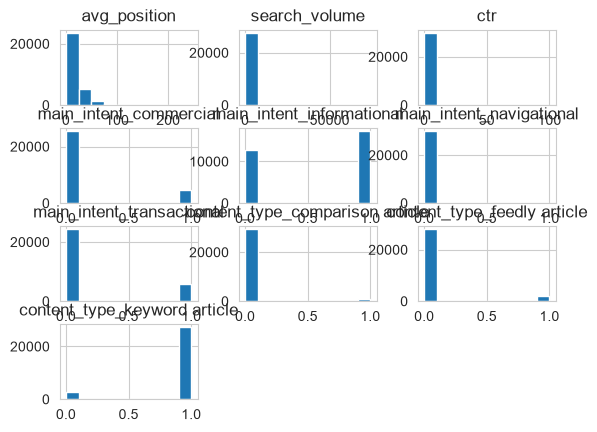

In [37]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
sns.set_style('whitegrid')
subset = df[['avg_position', 'search_volume', 'main_intent', 'content_type', 'ctr']]
subset = pd.get_dummies(subset, columns=['main_intent', 'content_type'], dtype='int')
subset.hist(bins=10)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

- **Signal Test #1: `avg_position`**
The data strongly supports the foundational SEO assumption that lower position numbers (better ranks) are a prerequisite for high click-through rates. **VERDICT: CONFIRMED**
- **Signal Test #2: `search_volume`**
High search volume actively correlates with a lower click-through rate, likely due to broad, highly competitive SERPs diluting the clicks. **VERDICT: OPPOSITE**
- **Signal Test #3: `main_intent`**
In this specific dataset, informational queries are the primary drivers of high-CTR discovery, while transactional pages struggle to capture clicks from the SERP. **VERDICT: MIXED**

<Axes: >

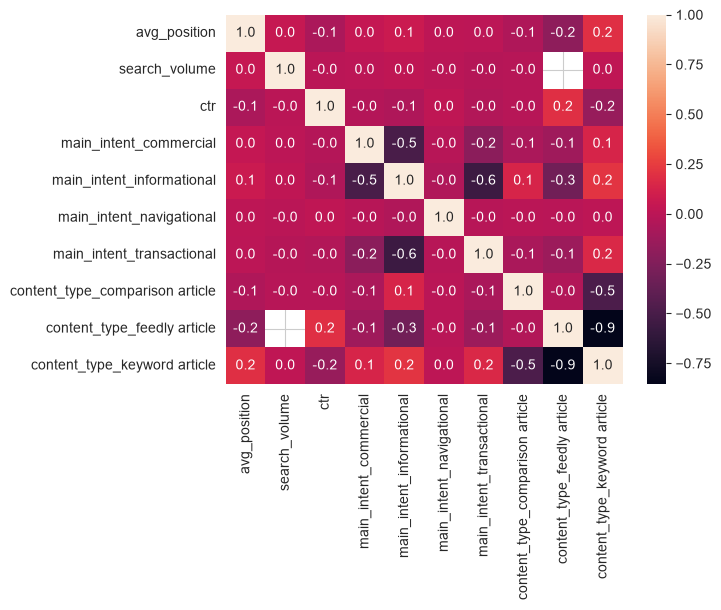

In [40]:
sns.heatmap(subset.corr(numeric_only=True), annot=True, fmt='.1f')

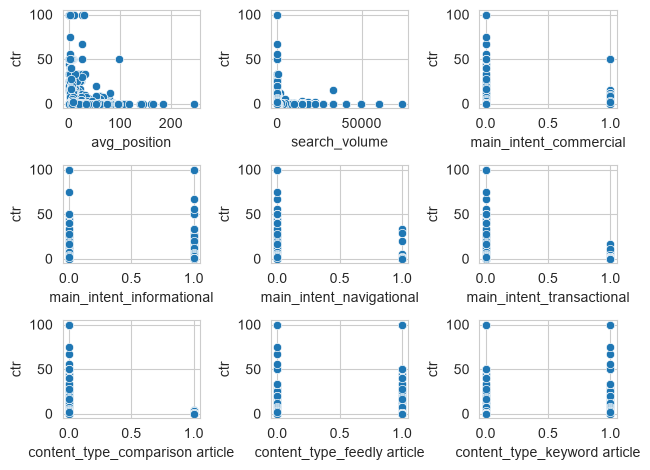

In [42]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
column = subset.drop('ctr', axis=1).columns.to_list()
fig, ax = plt.subplots(3, 3)

for i, cols in enumerate(column):
    sns.scatterplot(data=subset, x=cols, y='ctr', ax=ax.flat[i])

plt.tight_layout()

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*
- **Assumption:** "Ranking in the top 3 positions guarantees a high click-through rate."
- **Verdict:** FALSE. The measured data contradicts this assumption; filtering for `avg_position` <= 3 yields an observed mean CTR of only 1.47%.

In [53]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
pos_avg_thr = subset[subset['avg_position'] <= 3]
print(f"{pos_avg_thr.ctr.mean():.2f}")

1.47


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

- **Key Takeaways:** This analysis could provide directional insights to the content team on what metrics to study for when analyzing the CTR within specific points, specially in the position or ranking of a content. However, this should be taken with a grain of salt as click through rates does not just heavily rely on the contents that are highly ranked.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.